<a href="https://colab.research.google.com/github/GersonESantos/LLM-do-zero/blob/main/LLM_do_zero.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🐇 Build a Large Language Model From Scratch
## *The Wonderland Edition*

<a href="https://colab.research.google.com/github/priyankavergadia/llm-from-scratch-wonderland/blob/main/Build_an_LLM_From_Scratch_Wonderland.ipynb" target="_blank"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"></a>

> *"Begin at the beginning," the King said, very gravely, "and go on till you come to the end: then stop."*
> — Lewis Carroll, *Alice's Adventures in Wonderland*

Welcome. Over the next few hours you are going to build a working **GPT-style large language model** with your own hands. Not "call an API." Not "fine-tune with three lines of a library." You will write the tokenizer, the attention mechanism, the transformer block, the training loop — **all of it** — in plain PyTorch.

By the end you will have:

| # | What you build | What it does |
|---|---|---|
| 1 | 🎲 **The Dumbest Language Model** | Predicts the next word from one word of memory. Fails hilariously — and shows you exactly what a real LLM must fix. |
| 2 | ✂️ **A tokenizer** | Turns text into numbers. Two versions: yours, then GPT-2's real one. |
| 3 | 👁️ **Attention** | The idea that made all of this work. Built from a dot product upward. |
| 4 | 🏗️ **A full GPT** | The real GPT-2 small architecture — 12 transformer blocks, layer norm, GELU, residual connections, 163M parameters. |
| 5 | 🎓 **WonderGPT** | Your own model, trained by you, on *Alice in Wonderland*. It will learn to write like Lewis Carroll. Badly. Then less badly. |
| 6 | 🔍 **A classifier** | "Wonderland or Baker Street?" — fine-tune the model to tell Lewis Carroll from Arthur Conan Doyle. |
| 7 | 🐈 **Cheshire** | An instruction-following assistant. The same trick that turned GPT-3 into ChatGPT, at miniature scale. |

---

### How to read this notebook

Run every cell in order, top to bottom. Each **step** ends with a `🎯 Your turn` box — small experiments that are where the real learning happens. Skipping them is like reading about swimming.

**You do not need to know PyTorch.** Every code cell starts with a plain-English note on what it does, every tensor is labelled with its shape, and each PyTorch trick is explained the first time it appears. If a line looks like magic, there is a comment on it.

**A promise:** nothing here is magic. Every single line is arithmetic you already know — multiply, add, average, compare. The astonishing part is not any individual step. It is that the steps, stacked deep enough and fed enough text, start to *talk back*.

*Based on the book [Build a Large Language Model (From Scratch)](https://www.manning.com/books/build-a-large-language-model-from-scratch) by Sebastian Raschka, chapters 1–7, restaged with new examples and a new cast.*

<p style="text-align:center">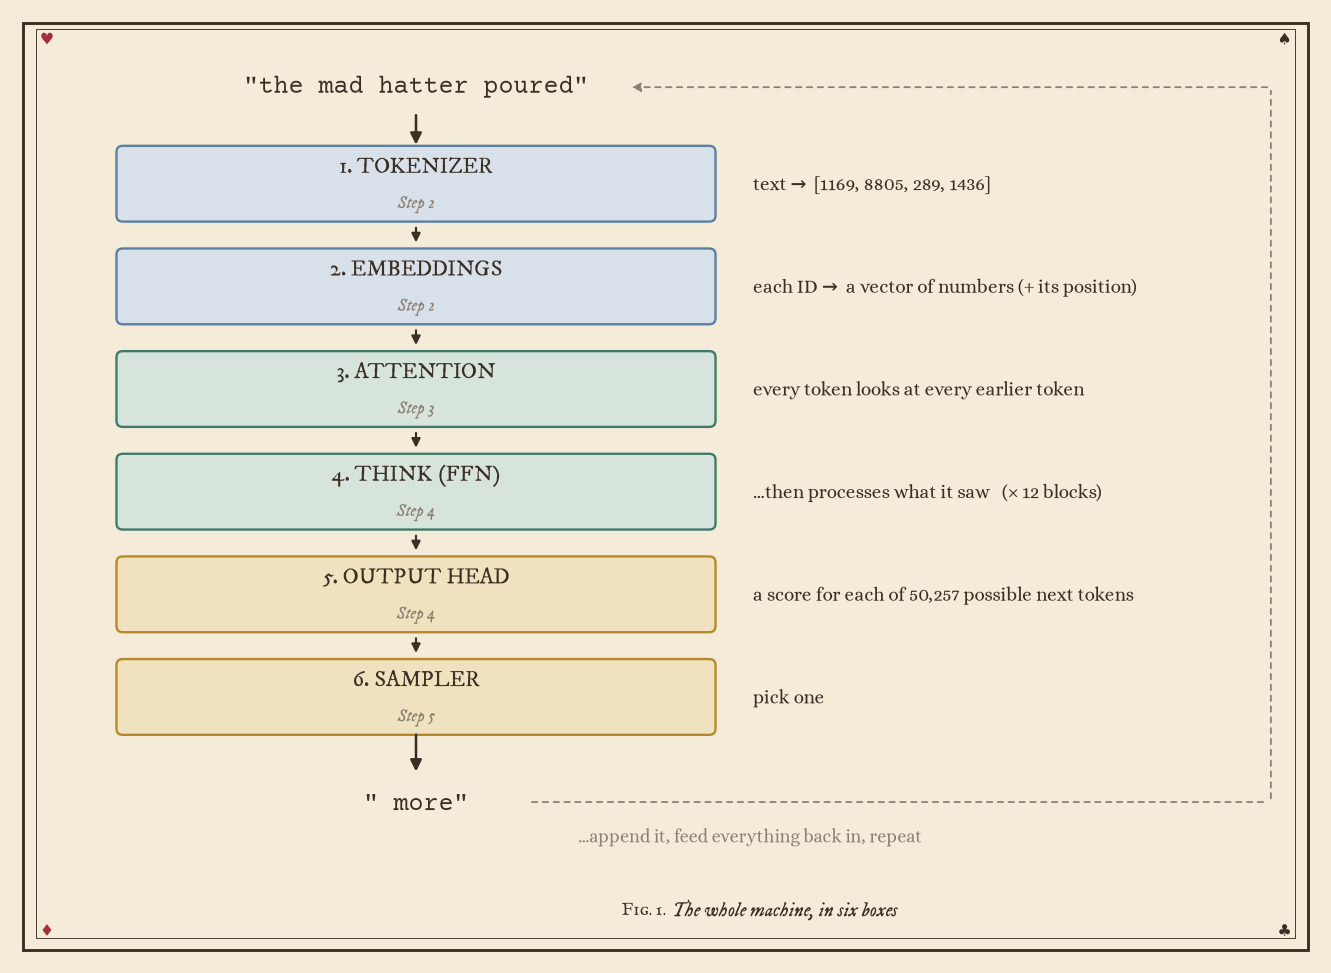</p>

In [5]:
# ── What this cell does ─────────────────────────────────────────────────────
# Installs the one library Colab doesn't ship with (tiktoken = GPT-2's tokenizer),
# then prints the version of each library so you know what you're running.
# The "%pip" at the start is a Jupyter/Colab command, not Python — it runs pip
# inside this notebook's environment.

%pip install -q tiktoken

from importlib.metadata import version     # a tiny helper that reads a package's version string

for pkg in ["torch", "tiktoken", "matplotlib"]:
    try:
        print(f"{pkg:<12} {version(pkg)}")   # {pkg:<12} = left-align in a 12-character column
    except Exception:
        print(f"{pkg:<12} ❌ NOT INSTALLED  ->  pip install {pkg}")

torch        2.11.0+cpu
tiktoken     0.14.0
matplotlib   3.10.0


In [1]:
# ── What this cell does ─────────────────────────────────────────────────────
# 1. Imports PyTorch, the library that does all the math for us.
# 2. Picks the fastest hardware available (GPU if you have one, else CPU).
# 3. Sets a FAST switch you can flip to trade quality for speed.
# 4. Defines free(), a tiny cleanup helper we'll call after finishing with big models.

import torch      # PyTorch: tensors (multi-dimensional arrays) + automatic gradients + GPU support


def pick_device():
    """Return the best place to run our math: 'cuda' (NVIDIA GPU), 'mps' (Apple GPU), or 'cpu'."""
    if torch.cuda.is_available():                    # is there an NVIDIA GPU? (Colab T4 -> yes)
        return torch.device("cuda")
    if torch.backends.mps.is_available():            # Apple Silicon GPU?
        major, minor = map(int, torch.__version__.split(".")[:2])
        if (major, minor) >= (2, 9):                 # older MPS builds have numerical quirks
            return torch.device("mps")
    return torch.device("cpu")                       # always works, just slower


device = pick_device()
print("Running on:", device)
if device.type == "cpu":
    print("  ⚠️  No GPU found. Everything still works, but Steps 5-7 will be slow.")
    print("     On Colab: Runtime -> Change runtime type -> T4 GPU.")


# ── Speed dial ──────────────────────────────────────────────────────────────
# FAST = True  -> shorter training runs. Great for a first pass or a live demo.
# FAST = False -> the real thing. Better results, longer waits.
FAST = True
print(f"FAST mode: {FAST}  (flip this at the top of Step 0 to change it)")


# ── Housekeeping ────────────────────────────────────────────────────────────
# LLMs are memory hogs. When we're done with a model we `del` it and call free()
# so the next step has room. (Python's garbage collector is lazy; this nudges it.)
import gc

def free():
    """Run after `del some_model` to actually reclaim the memory."""
    gc.collect()                                     # Python: release unreferenced objects
    if device.type == "cuda":
        torch.cuda.empty_cache()                     # GPU: hand cached memory back
    elif device.type == "mps":
        torch.mps.empty_cache()

print("\n💾 Each 124M-parameter model here is ~650 MB, and training needs several times")
print("   that. We free models as we finish with them so the later steps have room.")

Running on: cuda
FAST mode: True  (flip this at the top of Step 0 to change it)

💾 Each 124M-parameter model here is ~650 MB, and training needs several times
   that. We free models as we finish with them so the later steps have room.


📎 PyTorch in twelve lines
Everything in this notebook is built from a handful of tensor operations. Skim this now; come back whenever a line of code looks strange. Every one of these shows up again with a comment at the point of use.

In [2]:
# ── A pocket reference. Run it, read the output, move on. ───────────────────
t = torch.tensor([[1., 2., 3.],
                  [4., 5., 6.]])                     # a 2-D tensor: 2 rows x 3 columns

print("shape        ", t.shape)                     # torch.Size([2, 3])  <- rows, columns
print("t[1]         ", t[1])                        # indexing: the second row (Python counts from 0)
print("t[:, 0]      ", t[:, 0])                     # ':' means 'all rows'; ', 0' picks column 0
print("t.T          ", t.T.shape)                   # transpose: swap rows and columns -> (3, 2)
print("t @ t.T      ", (t @ t.T).shape)             # '@' is matrix multiplication -> (2, 2)
print("t * 2        ", (t * 2)[0])                  # '*' is element-wise (each number separately)
print("sum(dim=-1)  ", t.sum(dim=-1))               # dim=-1 = 'along the LAST axis' -> one sum per row
print("keepdim      ", t.sum(dim=-1, keepdim=True).shape)  # keep the axis so shapes still line up: (2, 1)
print("softmax      ", torch.softmax(t, dim=-1)[0]) # turn a row of scores into probabilities that sum to 1
print("argmax       ", t.argmax(dim=-1))            # index of the biggest value in each row
print("view         ", t.view(3, 2).shape)          # reshape without copying (same 6 numbers, new grid)
print("item()       ", t[0, 0].item())              # pull a single number out as a plain Python float

# Two more ideas you'll meet:
#   torch.no_grad()  -> "don't track gradients here" (faster; used when we're only predicting, not learning)
#   .to(device)      -> move a tensor or model onto the GPU

shape         torch.Size([2, 3])
t[1]          tensor([4., 5., 6.])
t[:, 0]       tensor([1., 4.])
t.T           torch.Size([3, 2])
t @ t.T       torch.Size([2, 2])
t * 2         tensor([2., 4., 6.])
sum(dim=-1)   tensor([ 6., 15.])
keepdim       torch.Size([2, 1])
softmax       tensor([0.0900, 0.2447, 0.6652])
argmax        tensor([2, 2])
view          torch.Size([3, 2])
item()        1.0


### 📚 Our text: two very different books

Every language model is a mirror of what it read. We are going to feed ours two public-domain classics that could not be less alike:

| | Book | Vibe |
|---|---|---|
| 🐇 | *Alice's Adventures in Wonderland* — Lewis Carroll, 1865 | dream logic, talking animals, unhinged tea |
| 🔎 | *The Adventures of Sherlock Holmes* — Arthur Conan Doyle, 1892 | fog, deduction, cigar ash taxonomy |

*Alice* is our main training text (Steps 1–5). In Step 6 we bring in *Sherlock* and teach the model to tell the two authors apart.

Why *Alice*? Partly because it is short, free, and famous. Mostly because when a half-trained model produces beautiful nonsense — and it will — nonsense is exactly the house style.

In [3]:
# ── What this cell does ─────────────────────────────────────────────────────
# Downloads both books from Project Gutenberg (once; they're cached on disk),
# strips the legal boilerplate and table of contents, and keeps the story text.
# At the end, `alice` is one long Python string holding the whole novel.

import os                      # files and paths
import re                      # regular expressions: pattern matching in text
import urllib.request          # downloading from a URL

BOOKS = {
    "alice":    ("https://www.gutenberg.org/files/11/11-0.txt",     "alice.txt"),
    "sherlock": ("https://www.gutenberg.org/files/1661/1661-0.txt", "sherlock.txt"),
}

def download(url, path):
    """Fetch a file once and cache it on disk. Skips the download if the file exists."""
    if os.path.exists(path):
        return
    req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})   # some sites refuse bare requests
    with urllib.request.urlopen(req, timeout=60) as r, open(path, "wb") as f:
        f.write(r.read())
    print(f"downloaded -> {path}")

def strip_gutenberg(raw):
    """Cut away the Project Gutenberg legal text, keep only the story."""
    # The story sits between two marker lines. re.S lets '.' match across line breaks,
    # because some books wrap the marker onto two lines.
    start = re.search(r"\*\*\* START OF (THE|THIS) PROJECT GUTENBERG.*?\*\*\*", raw, re.S)
    end   = re.search(r"\*\*\* END OF (THE|THIS) PROJECT GUTENBERG.*?\*\*\*",   raw, re.S)
    body = raw[start.end():end.start()] if (start and end) else raw
    body = body.replace("\r\n", "\n")                        # Windows line endings -> Unix
    body = re.sub(r"\n{3,}", "\n\n", body)                   # squash runs of blank lines
    # drop table-of-contents lines: indented, like "  IV.  Title" or " CHAPTER I.  Title"
    body = re.sub(r"^[ \t]+((CHAPTER\s+)?[IVXL]+\.)[ \t]+\S.*$\n?", "", body, flags=re.M)
    return re.sub(r"\n{3,}", "\n\n", body).strip()

texts = {}
for name, (url, path) in BOOKS.items():
    download(url, path)
    with open(path, "r", encoding="utf-8") as f:
        texts[name] = strip_gutenberg(f.read())
    print(f"{name:<9} {len(texts[name]):>7,} characters")    # {:>7,} = right-align, thousands separators

alice = texts["alice"]        # the string we'll use for most of the notebook
print("\n--- first 350 characters of our training text ---\n")
print(alice[:350])            # [:350] = the first 350 characters (string slicing)

downloaded -> alice.txt
alice     144,065 characters
downloaded -> sherlock.txt
sherlock  561,660 characters

--- first 350 characters of our training text ---

[Illustration]

Alice’s Adventures in Wonderland

by Lewis Carroll

THE MILLENNIUM FULCRUM EDITION 3.0

Contents

CHAPTER I.
Down the Rabbit-Hole

Alice was beginning to get very tired of sitting by her sister on the
bank, and of having nothing to do: once or twice she had peeped into
the book her sister was reading, but it had no pictures or
conve


---
# 🎲 Step 1 · The Dumbest Language Model in the World
### *(Chapter 1: what an LLM actually is)*

Before we build something impressive, let's build something **terrible** — on purpose. It takes ten lines, it runs instantly, and it will teach you more about why transformers exist than any diagram.

**The rules of the game.** Read all of *Alice*. For every word, write down which words came after it. To generate text: look at the last word, and roll a weighted die over the words that followed it in the book.

That's it. That is a real (if ancient) language model — a *bigram* model. It has exactly **one word of memory**.

In [4]:
# ── What this cell does ─────────────────────────────────────────────────────
# "Trains" the bigram model: for every word in the book, count which words came
# right after it. The whole model is one dictionary of counters.

import random
from collections import defaultdict, Counter
# Counter    = a dict that counts things:  Counter("aab") -> {'a': 2, 'b': 1}
# defaultdict = a dict that creates a missing key on first touch instead of erroring

# Chop the book into lowercase words (letters and apostrophes only; punctuation is dropped)
words = re.findall(r"[a-zA-Z']+", alice.lower())
print(f"{len(words):,} words in Wonderland\n")

# follows["alice"] will be a Counter of every word that ever came after "alice"
follows = defaultdict(Counter)
for current_word, next_word in zip(words, words[1:]):   # zip pairs each word with the one after it
    follows[current_word][next_word] += 1

# Peek at what the model "knows"
for w in ["alice", "queen", "very", "tea"]:
    top = ", ".join(f"{nxt} ({n})" for nxt, n in follows[w].most_common(5))
    print(f"after '{w}':  {top}")

27,350 words in Wonderland

after 'alice':  and (20), was (17), i (16), s (12), thought (12)
after 'queen':  and (7), s (7), said (5), of (4), was (4)
after 'very':  much (10), soon (7), curious (6), glad (5), politely (5)
after 'tea':  the (3), time (2), party (2), and (2), at (1)


In [5]:
# ── What this cell does ─────────────────────────────────────────────────────
# Generates text: start from a word, look up what followed it in the book,
# pick one at random (weighted by how often it appeared), repeat.

def dumb_generate(seed_word, n_words=40, seed=7):
    """Roll a weighted die over 'what came next in the book', one word at a time."""
    rng = random.Random(seed)              # a seeded random generator, so results are repeatable
    out = [seed_word]
    for _ in range(n_words):
        options = follows[out[-1]]         # out[-1] = the LAST word generated so far (all we look at!)
        if not options:                    # dead end (a word that only ever ended the book) -> restart
            out.append(rng.choice(words))
            continue
        candidates  = list(options.keys())     # the possible next words
        frequencies = list(options.values())   # how often each one followed
        out.append(rng.choices(candidates, weights=frequencies)[0])   # weighted random pick
    return " ".join(out)

print("🎲 THE DUMBEST LANGUAGE MODEL SAYS:\n")
print(dumb_generate("alice"))
print()
print(dumb_generate("the", seed=99))

🎲 THE DUMBEST LANGUAGE MODEL SAYS:

alice felt that is the queen the house if i can t be said the other ladder why what are old conger eel that it was going to it was in my own business there was no chance of its voice

the others we had been would not notice of white but alas for any of escape so much the little of meaning and considered a cushion resting their own mind that came running out now tell it s the court of


What just happened
Look closely at that output. Two things are true at once:

✅ It is not random. "alice was" is plausible. "the queen" is plausible. Local pairs of words genuinely sound like English, because they were English.

❌ It has no idea what it is saying. The sentence falls apart after about four words. It forgets its own subject. It cannot close a quotation mark it opened. It will happily write "the King of the King of the King."

Why? Because the model's entire memory is one word. When it is choosing the word after "said", it does not know whether the sentence started with Alice or the Mad Hatter. All the context has evaporated.